# Quickstart

Run the reference week, look at what the naive household does to the feeder, and
score your own idea.

Everything below takes about a minute end to end.

In [1]:
%load_ext autoreload
%autoreload 2

# Picks up edits to sandbox/*.py (my_idea, controller, tariff, ...) on the next
# cell run -- no kernel restart needed. Edit sandbox/my_idea.py, re-run cell 12,
# and you will see the change.

In [2]:
import jax
import jax.numpy as jnp

from sandbox.controller import base_controller, passive_controller
from sandbox.metrics import compare, fairness, score
from sandbox.rollout import build_env, rollout
from sandbox.scenarios import end_of_line_impedance_ohm, reference_scenario

population = reference_scenario()
env = build_env(population)

print(f"{population.num_pq} connection points, {population.num_agents} of them agents")
print(f"end-of-line impedance: {end_of_line_impedance_ohm():.3f} ohm")
for name in ("tenant", "pv_only", "pv_battery", "large_flex"):
    print(f"  {name:<12} {population.type_of_pq.count(name)}")

18 connection points, 12 of them agents
end-of-line impedance: 0.912 ohm
  tenant       6
  pv_only      2
  pv_battery   6
  large_flex   4


## The pathology

`passive` never touches the battery. `self_consumption` is what every home
battery ships with: fill from your own roof, empty into your own evening. It is
better for the household on every measure the household can see.

One column decides whether this feeder needs a bigger transformer:
`export_pk_kW`. Watch that one. Then watch the second table, which is who paid.


In [3]:
scores = {}
for controller in (passive_controller(), base_controller()):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    scores[controller.name] = score(trajectory, population)

print(compare(scores))
print()
print(fairness(scores))

                   export_pk_kW   draw_pk_kW      reverse      coincid       pk/avg      ramp_kW         sync         loss      curtail     selfcons          CHF        >1.05
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
passive                    69.4         18.4          46%        0.805         2.83          6.9        +0.27        8.82%         0.8%          14%          299       12.98%
self_consumption           66.8          8.2          41%        0.773         3.57         16.1        +0.59        9.09%         1.4%          28%          332       10.49%

CHF/kWh consumed, by household type
                         tenant      pv_only   pv_battery   large_flex       spread  tenant_import
--------------------------------------------------------------------------------------------------
passive                  +0.223       -0.209       -0.954       -

### The export peak barely moves

**69.4 kW to 66.8 kW. Two per cent.** That is the whole network result, and it
is the number the money would be spent on: the transformer, the cables and the
planning assumptions are sized by the worst export interval of the year, not by
how much solar anybody self-consumed.

Why so little? Every battery is full hours before the peak it would have to
absorb. The plot below is one day — the curves separate all morning, and from
11:00 they lie on top of each other. At the moment the feeder is under most
strain the two controllers are doing exactly the same thing. Twelve batteries
bought and installed, and the constraint that binds is untouched.

Meanwhile the household's own numbers all improve: self-consumption 14 % → 28 %,
the evening draw peak halved, a bigger cheque. **The household optimises one
quantity and the network is sized by another.** That gap is the whole challenge:
a tariff has to make the second quantity visible in the first.

The two smaller network effects both concern the *shape* of the week rather
than its size. The same work is squeezed into a narrower window (`pk/avg`, 2.83
→ 3.57) and the steepest interval-to-interval swing roughly doubles (`ramp_kW`,
6.9 → 16.1), because twelve batteries saturate inside the same hour and stop
absorbing together — which `sync` reads directly, 0.27 → 0.59.

`sync` is read off the battery flow rather than off the household's own
quantities, because those are already synchronised before anyone controls
anything: the inverter power a household requests and the `p_grid_kw` it is
billed on both score **+0.87 for `passive`**, a fleet that coordinates nothing.
Twelve roofs share one sky and twelve households cook at seven. That number is
the premise of this challenge in one figure.

Of the three, weigh `pk/avg` heaviest: it is the whole week, while `ramp_kW` is
one interval out of 671.

### Who won, who lost, and who would sign

Now the fairness table, which is where the interesting damage is.

| | passive | self-consumption | |
|---|---|---|---|
| tenant | +0.223 | **+0.223** | unchanged — no roof, nothing to change |
| pv_only | −0.209 | −0.213 | unchanged — a roof, no battery |
| pv_battery | −0.954 | **−7.829** | 8× better off |
| large_flex | −0.242 | −1.379 | 5× better off |
| tenants' share of imports | 32 % | **64 %** | |

The battery households stop buying: their grid imports fall by roughly seven
eighths. Nothing replaces that. The six tenants keep importing exactly what they
always did, so their share of everything the feeder draws goes from a third to
two thirds — and any network charge, being recovered from what households buy,
follows them there. The network did not get cheaper. It got cheaper *for the
people who could afford a battery*.

So put the participation question to it, because it is the one a real tariff has
to survive. **Would every party sign this?**

- **pv_battery, large_flex** — yes, enthusiastically. Large private gain.
- **pv_only** — indifferent. Nothing happened to them either way.
- **tenants** — no. They pay the same per kWh for a network whose costs they now
  carry twice the share of, and they were never offered a way out.
- **the network operator** — no. Two per cent off the constraint that sizes the
  asset, a sharper feeder, and a cost base that has just halved.

An outcome that two of five parties would refuse is not a tariff; it is a
transfer that happened to be legal. Your submission has to be able to answer
this question with a yes from everyone — or say precisely which group it is
narrowed to, and why the ones outside it are unaffected.

And note what is absent from all of this: **there is no price anywhere in the
experiment.** Nobody was paid to synchronise. The correlation is in the weather
and the working day.


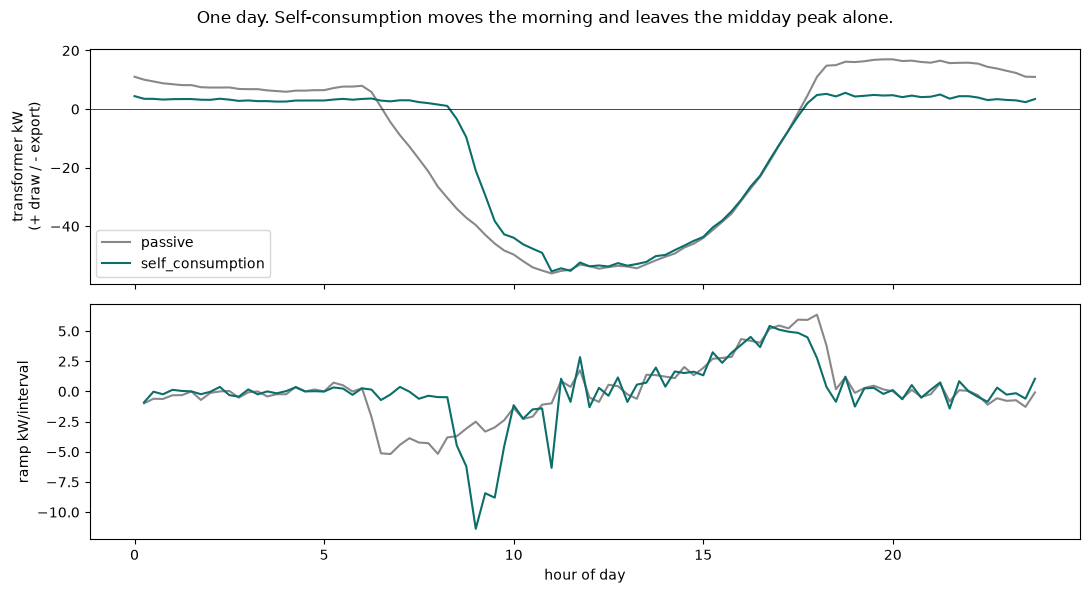

In [4]:
# gll_env pulls in jumanji, which switches matplotlib to the ipympl widget
# backend on import inside a notebook. That needs a JS bundle per figure and
# renders nothing when it is missing, so switch back to static inline PNGs.
%matplotlib inline

import matplotlib.pyplot as plt

from sandbox.export import feeder_dataframe

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for controller, colour in ((passive_controller(), "#888"), (base_controller(), "#0b6e6b")):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    # One calendar day. `day` counts midnights rather than dividing the step
    # index, because an episode does not start at midnight -- so `hour` runs
    # 0 to 24 in order and the line does not wrap back across the axis.
    feeder = feeder_dataframe(trajectory).query("day == 2").sort_values("hour")
    axes[0].plot(feeder.hour, feeder.transformer_kw, color=colour, label=controller.name)
    axes[1].plot(feeder.hour.iloc[1:], feeder.transformer_kw.diff().iloc[1:], color=colour)

axes[0].set_ylabel("transformer kW\n(+ draw / - export)")
axes[0].legend()
axes[0].axhline(0, lw=0.5, color="k")
axes[1].set_ylabel("ramp kW/interval")
axes[1].set_xlabel("hour of day")
fig.suptitle("One day. Self-consumption moves the morning and leaves the midday peak alone.")
plt.tight_layout()

## What one household can see

No price anywhere in it. Note which interval each field describes: `p_load_kw`
and `voltage_pu` are what just happened, `p_load_forecast_kw` and
`pv_available_kw` are the interval you are about to act in.

The controller returns the **inverter**'s power, `p_inv_kw`. What the feeder
carries — and what the tariff settles — is `p_inv_kw - p_load_kw`.

In [5]:
from sandbox.observation import to_local

state, timestep = env.reset(jax.random.PRNGKey(0))
local = to_local(env.environment, timestep.observation, state)

for name, values in local.as_dict().items():
    print(f"{name:<22} {jnp.round(values[:4], 2)}")

hour                   [3.5 3.5 3.5 3.5]
time_sin               [0.81 0.81 0.81 0.81]
time_cos               [0.58 0.58 0.58 0.58]
voltage_pu             [0.97999996 0.97999996 0.97999996 0.97999996]
p_grid_kw              [-0.55      -1.4       -1.9599999  3.37     ]
p_load_kw              [0.55       0.39       0.17999999 0.14999999]
p_load_forecast_kw     [0.48999998 0.28       0.17       0.14999999]
pv_available_kw        [0. 0. 0. 0.]
soc_kwh                [0.         9.04       3.1899998  0.78999996]
soc_headroom_kwh       [ 0.         3.9599998  9.809999  12.21     ]
bat_charge_max_kw      [0. 5. 5. 5.]
bat_discharge_max_kw   [0.        5.        5.        3.1499999]
p_inv_min_kw           [-0. -5. -5. -5.]
p_inv_max_kw           [0.        5.        5.        3.1499999]


## What the network can see

The tariff's turn: after the interval solves, it sees the whole feeder, not
one meter. `grid.e_grid_kwh` is each connection point's net **active**
exchange with the grid, inverter output minus household load — the quantity
the baseline settles.

A network operator also measures **reactive** power, so `grid.q_grid_kvar`
and `grid.transformer_kvar` are here too. A household never chooses those
(the Q(U) grid code does), which makes pricing them a trap worth reading
about in [`TARIFF_COOKBOOK.md`](../TARIFF_COOKBOOK.md) before you try.

`grid.fair_leg_chf` is zero here, because this cell steps the model directly
with no tariff in the loop; in a real rollout it is the finished CHF
settlement the fair-LEG baseline would produce.

In [6]:
from sandbox.observation import to_grid_view

model = env.environment
new_state, _ = model.step(state, jnp.zeros((model.num_agents, model.action_dim), jnp.float32))
grid = to_grid_view(model, new_state)

for name, values in (
    ("e_grid_kwh", grid.e_grid_kwh),
    ("p_grid_kw", grid.p_grid_kw),
    ("q_grid_kvar", grid.q_grid_kvar),
    ("voltage_pu", grid.voltage_pu),
):
    print(f"{name:<14} {jnp.round(values[:4], 2)}")
print(f"{'transformer':<14} {grid.transformer_kw:.2f} kW   {grid.transformer_kvar:.2f} kvar")

e_grid_kwh     [-0.07 -0.04 -0.09 -0.06]
p_grid_kw      [-0.26999998 -0.17       -0.35999998 -0.25      ]
q_grid_kvar    [-0.09 -0.05 -0.12 -0.08]
voltage_pu     [1.         1.         1.         0.98999995]
transformer    7.09 kW   2.34 kvar


## Now make it yours

Open **`sandbox/my_idea.py`**. Two functions, both naive working defaults you
are meant to overwrite -- a household controller and a grid tariff (a full
settlement, not a bolt-on charge). Edit either or both, then run the cell
below.

`check()` takes about ten seconds and is for iterating. It prints the same two
tables as above — the feeder, then who paid — against the reference.

On a fresh checkout every *physical* row is identical, and it says so: the
default `my_controller` **is** the reference controller. The fairness rows
still move, because the default `my_tariff` rebates its congestion term
equally over all eighteen connection points. That is worth looking at before
you change anything: a tariff redistributing hard while not moving a single
kilowatt is the normal case, not a broken one.

**`check()` does not tune, so it cannot show a tariff working on the feeder** —
no household sees a price during an episode, so a price can only move money
here, never behaviour. `score()` re-tunes households against your tariff first,
runs the full week over twenty weathers, and takes about three minutes. It is
what the jury sees.

For more room than one function each: [`CONTROLLER_COOKBOOK.md`](../CONTROLLER_COOKBOOK.md)
and [`TARIFF_COOKBOOK.md`](../TARIFF_COOKBOOK.md).

In [7]:
from sandbox.my_idea import check

check(days=3)

            export_pk_kW      coincid       pk/avg      ramp_kW      curtail          CHF
-----------------------------------------------------------------------------------------
reference           64.2        0.771         3.48         11.5         0.6%          127
yours               64.2        0.771         3.48         11.5         0.6%          127

CHF/kWh consumed, by household type
                  tenant      pv_only   pv_battery   large_flex       spread  tenant_import
-------------------------------------------------------------------------------------------
reference         +0.223       -0.390       -7.975       -0.763         8.20            60%
yours             -1.767       -1.065       +9.815       +0.957        11.58            60%

  solar exported at the worst moment        64.21 ->    64.21 kW    same
  work squeezed into the peak interval       3.48 ->     3.48       same
  worst sudden swing (herding)              11.54 ->    11.54 kW    same
  everyone acti

## Debugging

`fast=False` swaps the scan for a Python loop and the vmap for a list
comprehension. Values become concrete, so `if` and `print` work and the
traceback points at your line. Same answer; about 100× slower per interval,
which is `check()`'s ten seconds becoming eighty.

Or write the whole thing in NumPy — see `sandbox/numpy_bridge.py`. That tier
is for prototyping: it costs about 8× on a tuning sweep, so port to `jnp`
before you start iterating on `score()`.

In [8]:
trajectory = rollout(
    base_controller(), population, jax.random.PRNGKey(0), n_steps=8, env=env, fast=False
)
print("p_inv_kw, first interval:", jnp.round(trajectory.p_inv_set_kw[0], 2))

p_inv_kw, first interval: [0.78999996 0.25       0.71       0.77       0.03       0.29999998
 2.06       1.8399999  1.52       0.08       0.68       0.7       ]


## Out to pandas

No JAX beyond this point — the fairness audit and any visualisation can be done
entirely in tools you already know. All eighteen connection points are here,
tenants included; they have no agent and are missing from anything indexed by
one. `distance_rank` orders them by electrical distance from the transformer,
0 nearest.

In [9]:
from sandbox.export import to_dataframe

trajectory = rollout(base_controller(), population, jax.random.PRNGKey(0), env=env)
frame = to_dataframe(trajectory, population, label="self_consumption")

frame.groupby("household").agg(
    settlement_chf=("settlement_chf", "sum"),
    mean_grid_kw=("p_grid_kw", "mean"),
    mean_grid_kvar=("q_grid_kvar", "mean"),
    mean_inverter_kw=("p_inv_set_kw", "mean"),
    peak_voltage_pu=("voltage_pu", "max"),
).round(2)

,settlement_chf,mean_grid_kw,mean_grid_kvar,mean_inverter_kw,peak_voltage_pu
household,,,,,
large_flex,124.129997,1.43,-1.57,2.57,1.11
pv_battery,273.420013,2.01,-0.90,2.51,1.08
pv_only,18.080000,0.53,-0.33,0.99,1.06
tenant,-83.790001,-0.37,-0.12,NaN,1.05


## Handing it in

Fork, branch, commit `sandbox/my_idea.py`, open a pull request.

**We are judging the idea, not the code.** The PR description is the
submission — how your tariff is calculated in words, which grid operation cost
you set out to internalise, how a household could see it coming, who gains and
who loses across all five parties, what you would have wanted to measure and
could not, what would stop it reaching a real bill, and where you would go
next. [`README.md`](../README.md#handing-it-in) has the full list.

A clearly reasoned mechanism with a mediocre `score()` beats a tuned one
nobody can explain.
